In [2]:
# Cell 1: Import all required libraries for data processing, visualization, and machine learning
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns  # For statistical data visualization

# Data preprocessing modules
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn.preprocessing import StandardScaler, LabelEncoder  # For feature scaling and encoding categorical variables

# Machine learning algorithms
from sklearn.linear_model import LogisticRegression  # Logistic Regression classifier
from sklearn.tree import DecisionTreeClassifier  # Decision Tree classifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Suppress warning messages for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Cell 2: Load your dataset file into Google Colab
# This cell allows you to upload a CSV file from your computer

import io  # IMPORTANT: This was missing - needed for BytesIO
from google.colab import files  # Import Google Colab's file upload module

# Upload file - this will open a file selection dialog
print("📂 Please select your dataset CSV file...")
uploaded = files.upload()  # Opens file browser for you to select your CSV file

# Read the uploaded CSV file into a pandas DataFrame
# Get the filename from the uploaded dictionary
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
print("\n📋 First 5 rows of the dataset:")
df.head()  # Display first 5 rows to verify data

📂 Please select your dataset CSV file...


Saving credit_risk_dataset.csv to credit_risk_dataset (1).csv
✅ Dataset loaded successfully!
📊 Dataset shape: 5000 rows and 22 columns

📋 First 5 rows of the dataset:


,customer_id,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,...,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,CUST_00000,58,Male,Unemployed,58137.751192,115,524.679407,1,171.342369,49,...,16,1,539,5,14435.423445,2,0,0,15510.576882,1
1,CUST_00001,48,Male,Self-Employed,26174.922827,32,2635.203357,1,985.607164,1,...,1,2,494,5,11263.099341,2,0,0,14819.436498,1
2,CUST_00002,34,Other,Unemployed,75566.837265,14,2334.341061,9,994.310119,42,...,5,6,437,3,15017.144132,5,0,0,10909.806507,1
3,CUST_00003,62,Male,Self-Employed,35197.961516,179,2425.384332,10,366.115346,4,...,7,7,809,1,12626.138476,2,0,0,500.000000,0
4,CUST_00004,27,Female,Self-Employed,12136.998349,225,10.000000,8,786.752258,16,...,16,3,522,1,13576.704320,4,0,0,9514.591618,1


In [5]:
# Cell 3: Explore and understand the dataset structure and contents

print("="*50)
print("📊 DATASET INFORMATION")
print("="*50)
df.info()  # Shows data types, non-null counts, and memory usage

print("\n" + "="*50)
print("🔍 MISSING VALUES CHECK")
print("="*50)
print(df.isnull().sum())  # Count missing values in each column

print("\n" + "="*50)
print("📈 STATISTICAL SUMMARY")
print("="*50)
print(df.describe())  # Shows mean, std, min, max, quartiles for numerical columns

print("\n" + "="*50)
print("🎯 TARGET VARIABLE DISTRIBUTION")
print("="*50)
# Check distribution of credit_risk (0 = Safe, 1 = Risky/Default)
print(df['credit_risk'].value_counts())
print("\n📊 Percentage distribution:")
print(df['credit_risk'].value_counts(normalize=True) * 100)

📊 DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 5000 non-null   object 
 1   age                         5000 non-null   int64  
 2   gender                      5000 non-null   object 
 3   employment_status           5000 non-null   object 
 4   annual_income               5000 non-null   float64
 5   account_age_months          5000 non-null   int64  
 6   avg_monthly_balance         5000 non-null   float64
 7   num_deposits_per_month      5000 non-null   int64  
 8   avg_deposit_amount          5000 non-null   float64
 9   debit_card_usage_frequency  5000 non-null   int64  
 10  debit_card_spending         5000 non-null   float64
 11  mobile_banking_logins       5000 non-null   int64  
 12  online_transfer_frequency   5000 non-null   int64  
 13  atm_withdra

In [6]:
# Cell 4: Clean and preprocess the data for machine learning
# Handle missing values and encode categorical columns

print("🛠️ Starting data preprocessing...")

# Step 1: Handle missing values
if df.isnull().sum().sum() > 0:  # Check if any missing values exist
    print("⚠️ Missing values detected. Filling with median values...")
    # Fill numerical missing values with median (more robust than mean)
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:  # Only for numerical columns
            df[col].fillna(df[col].median(), inplace=True)
    print("✅ Missing values handled")
else:
    print("✅ No missing values found")

# Step 2: Encode categorical columns (convert text to numbers)
categorical_cols = df.select_dtypes(include=['object']).columns  # Find all categorical columns
label_encoders = {}  # Dictionary to store encoders for later use

print(f"\n📝 Found {len(categorical_cols)} categorical columns: {list(categorical_cols)}")

for col in categorical_cols:
    le = LabelEncoder()  # Create a LabelEncoder object
    df[col] = le.fit_transform(df[col])  # Convert text to numbers
    label_encoders[col] = le  # Save encoder for inverse transformation if needed
    print(f"   ✅ Encoded: {col}")

# Step 3: Drop unnecessary columns
if 'customer_id' in df.columns:
    df = df.drop('customer_id', axis=1)  # customer_id is not useful for prediction
    print("   ✅ Dropped 'customer_id' column")

print("\n✅ Preprocessing completed!")
print(f"📊 Final dataset shape: {df.shape}")
print("\n📋 First 5 rows after preprocessing:")
df.head()

🛠️ Starting data preprocessing...
✅ No missing values found

📝 Found 3 categorical columns: ['customer_id', 'gender', 'employment_status']
   ✅ Encoded: customer_id
   ✅ Encoded: gender
   ✅ Encoded: employment_status
   ✅ Dropped 'customer_id' column

✅ Preprocessing completed!
📊 Final dataset shape: (5000, 21)

📋 First 5 rows after preprocessing:


,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,...,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,58,1,2,58137.751192,115,524.679407,1,171.342369,49,768.877511,...,16,1,539,5,14435.423445,2,0,0,15510.576882,1
1,48,1,1,26174.922827,32,2635.203357,1,985.607164,1,580.287785,...,1,2,494,5,11263.099341,2,0,0,14819.436498,1
2,34,2,2,75566.837265,14,2334.341061,9,994.310119,42,564.013508,...,5,6,437,3,15017.144132,5,0,0,10909.806507,1
3,62,1,1,35197.961516,179,2425.384332,10,366.115346,4,838.489200,...,7,7,809,1,12626.138476,2,0,0,500.000000,0
4,27,0,1,12136.998349,225,10.000000,8,786.752258,16,462.495522,...,16,3,522,1,13576.704320,4,0,0,9514.591618,1


In [7]:
# Cell 5: Split the dataset into features (X) and target variable (y)
# X contains all input features used for prediction
# y contains the target variable we want to predict

print("🔍 Separating features and target variable...")

# Define target column
target_column = 'credit_risk'  # 1 = High Risk/Default, 0 = Low Risk/Safe

# Create feature matrix X (all columns except target)
X = df.drop(target_column, axis=1)

# Create target vector y (only the target column)
y = df[target_column]

print(f"✅ Features shape (X): {X.shape}")
print(f"✅ Target shape (y): {y.shape}")
print(f"\n📋 Feature columns ({len(X.columns)} features):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i}. {col}")

🔍 Separating features and target variable...
✅ Features shape (X): (5000, 20)
✅ Target shape (y): (5000,)

📋 Feature columns (20 features):
   1. age
   2. gender
   3. employment_status
   4. annual_income
   5. account_age_months
   6. avg_monthly_balance
   7. num_deposits_per_month
   8. avg_deposit_amount
   9. debit_card_usage_frequency
   10. debit_card_spending
   11. mobile_banking_logins
   12. online_transfer_frequency
   13. atm_withdrawal_frequency
   14. credit_score
   15. num_open_loans
   16. total_outstanding_debt
   17. late_payment_count
   18. loan_default_history
   19. fraud_flag
   20. loan_application_amount


In [8]:
# Cell 6: Split data into training and testing sets, then scale features
# Training set: used to train the model
# Testing set: used to evaluate model performance on unseen data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("🔪 Splitting dataset into training and testing sets...")

# Split data: 80% training, 20% testing
# stratify=y ensures same class distribution in both sets
# random_state=42 ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # Fixed seed for reproducibility
    stratify=y          # Maintain class balance
)

print(f"📊 Training set size: {X_train.shape[0]} samples")
print(f"📊 Testing set size: {X_test.shape[0]} samples")

# Step 2: Standardize features (scale to mean=0, standard deviation=1)
# This helps algorithms perform better
print("\n📏 Scaling features using StandardScaler...")
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)  # Learn parameters and transform
X_test_scaled = scaler.transform(X_test)        # Only transform using learned parameters

print("✅ Feature scaling completed!")
print(f"   Training data shape after scaling: {X_train_scaled.shape}")
print(f"   Testing data shape after scaling: {X_test_scaled.shape}")

🔪 Splitting dataset into training and testing sets...
📊 Training set size: 4000 samples
📊 Testing set size: 1000 samples

📏 Scaling features using StandardScaler...
✅ Feature scaling completed!
   Training data shape after scaling: (4000, 20)
   Testing data shape after scaling: (1000, 20)


In [9]:
# Cell 7: Train three different classification algorithms
# Each algorithm has different strengths and weaknesses

print("🤖 Training machine learning models...")
print("="*50)

# Model 1: Logistic Regression
# Good baseline model, works well for binary classification
print("\n📊 Training Logistic Regression...")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
print("   ✅ Logistic Regression trained successfully!")

# Model 2: Decision Tree
# Easy to interpret, captures non-linear relationships
print("\n📊 Training Decision Tree...")
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_clf.fit(X_train_scaled, y_train)
print("   ✅ Decision Tree trained successfully!")

# Model 3: Random Forest
# Ensemble method, usually gives best performance
print("\n📊 Training Random Forest...")
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_clf.fit(X_train_scaled, y_train)
print("   ✅ Random Forest trained successfully!")

print("\n" + "="*50)
print("🎉 All three models have been trained!")

🤖 Training machine learning models...

📊 Training Logistic Regression...
   ✅ Logistic Regression trained successfully!

📊 Training Decision Tree...
   ✅ Decision Tree trained successfully!

📊 Training Random Forest...
   ✅ Random Forest trained successfully!

🎉 All three models have been trained!


In [10]:
# Cell 8: Evaluate and compare all trained models using multiple metrics
# This helps us choose the best model for deployment

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Dictionary to store all models
models = {
    'Logistic Regression': log_reg,
    'Decision Tree': dt_clf,
    'Random Forest': rf_clf
}

# List to store results for comparison
results = []

print("📊 MODEL EVALUATION RESULTS")
print("="*60)

# Loop through each model and calculate metrics
for name, model in models.items():
    # Make predictions on test data
    y_pred = model.predict(X_test_scaled)

    # Get probability predictions for ROC-AUC
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Store results in dictionary
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    # Print individual model results
    print(f"\n{name}")
    print("-" * 30)
    print(f"   Accuracy:  {accuracy:.4f}  → ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f}  → ({precision*100:.2f}%)")
    print(f"   Recall:    {recall:.4f}  → ({recall*100:.2f}%)")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {roc_auc:.4f}")

# Create comparison table
print("\n" + "="*60)
print("📈 COMPLETE COMPARISON TABLE")
print("="*60)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Find and display the best model
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print(f"\n🏆 BEST MODEL: {best_model_name} (based on Accuracy)")

📊 MODEL EVALUATION RESULTS

Logistic Regression
------------------------------
   Accuracy:  0.9120  → (91.20%)
   Precision: 0.9302  → (93.02%)
   Recall:    0.9569  → (95.69%)
   F1-Score:  0.9434
   ROC-AUC:   0.9666

Decision Tree
------------------------------
   Accuracy:  1.0000  → (100.00%)
   Precision: 1.0000  → (100.00%)
   Recall:    1.0000  → (100.00%)
   F1-Score:  1.0000
   ROC-AUC:   1.0000

Random Forest
------------------------------
   Accuracy:  1.0000  → (100.00%)
   Precision: 1.0000  → (100.00%)
   Recall:    1.0000  → (100.00%)
   F1-Score:  1.0000
   ROC-AUC:   1.0000

📈 COMPLETE COMPARISON TABLE
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression     0.912   0.930203 0.956919  0.943372 0.966593
      Decision Tree     1.000   1.000000 1.000000  1.000000 1.000000
      Random Forest     1.000   1.000000 1.000000  1.000000 1.000000

🏆 BEST MODEL: Decision Tree (based on Accuracy)


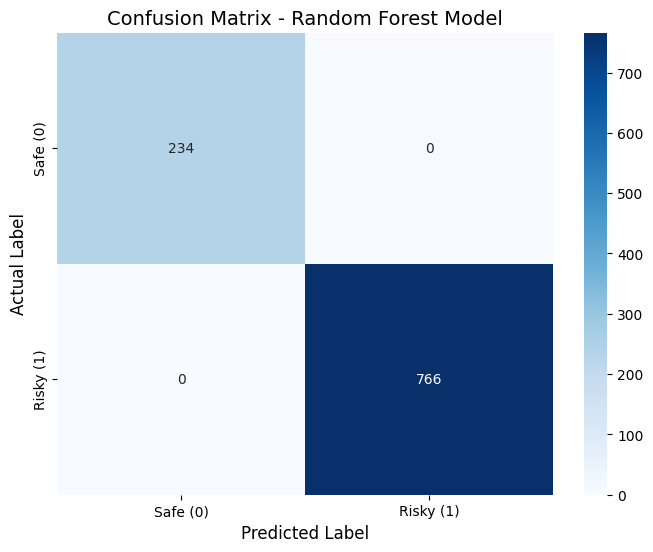


📖 CONFUSION MATRIX EXPLANATION:
Top-Left (TN): 234 - Safe customers correctly identified as Safe
Top-Right (FP): 0 - Safe customers wrongly marked as Risky
Bottom-Left (FN): 0 - Risky customers wrongly marked as Safe
Bottom-Right (TP): 766 - Risky customers correctly identified as Risky

📊 Additional Insights:
   False Positive Rate: 0.0000 (0.00%)
   False Negative Rate: 0.0000 (0.00%)


In [11]:
# Cell 9: Create confusion matrix for the best model (Random Forest)
# Confusion matrix shows: True Positives, True Negatives, False Positives, False Negatives

from sklearn.metrics import confusion_matrix

# Select the best model (Random Forest)
best_model = rf_clf
y_pred_best = best_model.predict(X_test_scaled)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Create a heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe (0)', 'Risky (1)'],
            yticklabels=['Safe (0)', 'Risky (1)'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix - Random Forest Model', fontsize=14)
plt.show()

# Explain the confusion matrix
print("\n📖 CONFUSION MATRIX EXPLANATION:")
print("="*50)
print(f"Top-Left (TN): {cm[0,0]} - Safe customers correctly identified as Safe")
print(f"Top-Right (FP): {cm[0,1]} - Safe customers wrongly marked as Risky")
print(f"Bottom-Left (FN): {cm[1,0]} - Risky customers wrongly marked as Safe")
print(f"Bottom-Right (TP): {cm[1,1]} - Risky customers correctly identified as Risky")

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"\n📊 Additional Insights:")
print(f"   False Positive Rate: {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)")
print(f"   False Negative Rate: {false_negative_rate:.4f} ({false_negative_rate*100:.2f}%)")

In [12]:
# Cell 10: Save the trained model and scaler for future use
# This allows you to use the model without retraining

import joblib  # Library for saving Python objects

print("💾 Saving model and preprocessing objects...")

# Save the trained Random Forest model
joblib.dump(rf_clf, 'credit_risk_model.pkl')
print("   ✅ Model saved as 'credit_risk_model.pkl'")

# Save the scaler for future data transformation
joblib.dump(scaler, 'scaler.pkl')
print("   ✅ Scaler saved as 'scaler.pkl'")

# Save the feature column names for consistency
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')
print("   ✅ Feature columns saved as 'feature_columns.pkl'")

print("\n✅ All files saved successfully!")
print("\n📁 Files saved in your Colab environment:")
print("   - credit_risk_model.pkl  (trained model)")
print("   - scaler.pkl             (feature scaler)")
print("   - feature_columns.pkl    (column names)")

# Download files to your computer (optional)
from google.colab import files
print("\n📥 To download files to your computer, run:")
print("   files.download('credit_risk_model.pkl')")
print("   files.download('scaler.pkl')")

💾 Saving model and preprocessing objects...
   ✅ Model saved as 'credit_risk_model.pkl'
   ✅ Scaler saved as 'scaler.pkl'
   ✅ Feature columns saved as 'feature_columns.pkl'

✅ All files saved successfully!

📁 Files saved in your Colab environment:
   - credit_risk_model.pkl  (trained model)
   - scaler.pkl             (feature scaler)
   - feature_columns.pkl    (column names)

📥 To download files to your computer, run:
   files.download('credit_risk_model.pkl')
   files.download('scaler.pkl')


In [13]:
# Cell 11: Test the trained model on real-world data
# This cell contains pre-defined customer data for testing

import joblib
import pandas as pd

print("="*60)
print("🎯 REAL-WORLD TEST - PREDEFINED CUSTOMER DATA")
print("="*60)

# Load the saved model and preprocessing objects
model = joblib.load('credit_risk_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_columns = joblib.load('feature_columns.pkl')

# Example 1: Low Risk Customer (Should get loan approved)
print("\n📋 TEST CASE 1: Low Risk Customer")
print("-"*40)

low_risk_customer = {
    'age': 35,
    'gender': 1,                    # 1 = Male, 0 = Female
    'employment_status': 2,         # 2 = Full-time
    'annual_income': 85000,         # $85,000 per year
    'account_age_months': 36,       # 3 years with bank
    'avg_monthly_balance': 7500,    # $7,500 average balance
    'num_deposits_per_month': 5,    # 5 deposits per month
    'avg_deposit_amount': 1500,     # $1,500 average deposit
    'debit_card_usage_frequency': 20,  # Uses debit card 20 times/month
    'debit_card_spending': 1200,    # $1,200 monthly spending
    'mobile_banking_logins': 25,    # 25 logins per month
    'online_transfer_frequency': 12,  # 12 transfers/month
    'atm_withdrawal_frequency': 4,  # 4 ATM withdrawals/month
    'credit_score': 780,            # Excellent credit score
    'num_open_loans': 1,            # Only 1 active loan
    'total_outstanding_debt': 10000,  # $10,000 debt
    'late_payment_count': 0,        # Never late
    'loan_default_history': 0,      # No default history
    'fraud_flag': 0,                # No fraud
    'loan_application_amount': 25000  # Asking for $25,000 loan
}

# Example 2: High Risk Customer (Should NOT get loan approved)
print("\n📋 TEST CASE 2: High Risk Customer")
print("-"*40)

high_risk_customer = {
    'age': 24,
    'gender': 1,
    'employment_status': 0,         # 0 = Unemployed
    'annual_income': 25000,         # Only $25,000 per year
    'account_age_months': 6,        # Only 6 months with bank
    'avg_monthly_balance': 500,     # Very low balance
    'num_deposits_per_month': 1,    # Few deposits
    'avg_deposit_amount': 200,      # Small deposits
    'debit_card_usage_frequency': 30,  # High usage
    'debit_card_spending': 2500,    # Spending more than income
    'mobile_banking_logins': 5,     # Few logins
    'online_transfer_frequency': 2,  # Few transfers
    'atm_withdrawal_frequency': 10,  # Many ATM withdrawals
    'credit_score': 520,            # Poor credit score
    'num_open_loans': 3,            # Multiple loans
    'total_outstanding_debt': 45000,  # High debt
    'late_payment_count': 6,        # Many late payments
    'loan_default_history': 1,      # Previous default
    'fraud_flag': 0,                # No fraud
    'loan_application_amount': 30000  # Asking for $30,000 loan
}

# Function to test a single customer
def test_customer(customer_data, customer_name):
    # Convert dictionary to DataFrame
    input_df = pd.DataFrame([customer_data])

    # Ensure all required columns exist in correct order
    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0

    # Reorder columns to match training data
    input_df = input_df[feature_columns]

    # Scale the input data
    input_scaled = scaler.transform(input_df)

    # Make prediction
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0]

    # Display results
    print(f"\n{customer_name}")
    print("="*40)

    if prediction == 1:
        print("❌ VERDICT: DO NOT GIVE LOAN")
        print("⚠️  Status: HIGH RISK CUSTOMER")
        print(f"📊 Risk Probability: {probability[1]*100:.2f}%")
        print(f"📊 Safe Probability: {probability[0]*100:.2f}%")
    else:
        print("✅ VERDICT: LOAN CAN BE GIVEN")
        print("🎉 Status: LOW RISK CUSTOMER")
        print(f"📊 Safe Probability: {probability[0]*100:.2f}%")
        print(f"📊 Risk Probability: {probability[1]*100:.2f}%")

# Test both customers
test_customer(low_risk_customer, "CUSTOMER 1: Low Risk Profile")
test_customer(high_risk_customer, "\nCUSTOMER 2: High Risk Profile")

print("\n" + "="*60)
print("💡 TIP: Use Cell 12 to test your own custom customer data!")

🎯 REAL-WORLD TEST - PREDEFINED CUSTOMER DATA

📋 TEST CASE 1: Low Risk Customer
----------------------------------------

📋 TEST CASE 2: High Risk Customer
----------------------------------------

CUSTOMER 1: Low Risk Profile
✅ VERDICT: LOAN CAN BE GIVEN
🎉 Status: LOW RISK CUSTOMER
📊 Safe Probability: 81.27%
📊 Risk Probability: 18.73%


CUSTOMER 2: High Risk Profile
❌ VERDICT: DO NOT GIVE LOAN
⚠️  Status: HIGH RISK CUSTOMER
📊 Risk Probability: 96.00%
📊 Safe Probability: 4.00%

💡 TIP: Use Cell 12 to test your own custom customer data!


In [14]:
# Cell 12: Interactive testing - Enter your own customer data manually
# Run this cell and type in your values when prompted

import joblib
import pandas as pd

print("="*60)
print("🔧 INTERACTIVE MODE - Test Your Own Customer")
print("="*60)
print("\nEnter the following customer details (press Enter after each value):")
print("-"*50)

# Load the saved model and preprocessing objects
model = joblib.load('credit_risk_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_columns = joblib.load('feature_columns.pkl')

# Collect input from user with try-except for error handling
try:
    # Basic customer information
    age = float(input("Enter age (e.g., 30): "))
    annual_income = float(input("Enter annual income in USD (e.g., 50000): "))
    credit_score = float(input("Enter credit score (300-850, e.g., 700): "))
    total_outstanding_debt = float(input("Enter total outstanding debt in USD (e.g., 15000): "))
    late_payment_count = float(input("Enter number of late payments (e.g., 0, 1, 2): "))
    loan_default_history = float(input("Any past loan default? (0 = No, 1 = Yes): "))
    loan_application_amount = float(input("Enter loan amount requested in USD (e.g., 20000): "))
    num_open_loans = float(input("Enter number of currently open loans (e.g., 1): "))
    avg_monthly_balance = float(input("Enter average monthly bank balance in USD (e.g., 5000): "))

    # Optional fields with default values
    print("\n📝 For the following fields, default values will be used if you press Enter:")

    gender_input = input("Gender (0 = Female, 1 = Male, default = 1): ")
    gender = float(gender_input) if gender_input else 1

    employment_input = input("Employment status (0 = Unemployed, 1 = Part-time, 2 = Full-time, default = 2): ")
    employment_status = float(employment_input) if employment_input else 2

    account_age = input("Account age in months (default = 12): ")
    account_age_months = float(account_age) if account_age else 12

    num_deposits = input("Number of deposits per month (default = 3): ")
    num_deposits_per_month = float(num_deposits) if num_deposits else 3

    avg_deposit = input("Average deposit amount in USD (default = 1000): ")
    avg_deposit_amount = float(avg_deposit) if avg_deposit else 1000

    debit_usage = input("Debit card usage frequency per month (default = 10): ")
    debit_card_usage_frequency = float(debit_usage) if debit_usage else 10

    debit_spending = input("Monthly debit card spending in USD (default = 800): ")
    debit_card_spending = float(debit_spending) if debit_spending else 800

    mobile_logins = input("Mobile banking logins per month (default = 15): ")
    mobile_banking_logins = float(mobile_logins) if mobile_logins else 15

    online_transfer = input("Online transfer frequency per month (default = 8): ")
    online_transfer_frequency = float(online_transfer) if online_transfer else 8

    atm_withdrawal = input("ATM withdrawal frequency per month (default = 5): ")
    atm_withdrawal_frequency = float(atm_withdrawal) if atm_withdrawal else 5

    fraud = input("Fraud flag (0 = No, 1 = Yes, default = 0): ")
    fraud_flag = float(fraud) if fraud else 0

    # Create customer data dictionary
    customer_data = {
        'age': age,
        'gender': gender,
        'employment_status': employment_status,
        'annual_income': annual_income,
        'account_age_months': account_age_months,
        'avg_monthly_balance': avg_monthly_balance,
        'num_deposits_per_month': num_deposits_per_month,
        'avg_deposit_amount': avg_deposit_amount,
        'debit_card_usage_frequency': debit_card_usage_frequency,
        'debit_card_spending': debit_card_spending,
        'mobile_banking_logins': mobile_banking_logins,
        'online_transfer_frequency': online_transfer_frequency,
        'atm_withdrawal_frequency': atm_withdrawal_frequency,
        'credit_score': credit_score,
        'num_open_loans': num_open_loans,
        'total_outstanding_debt': total_outstanding_debt,
        'late_payment_count': late_payment_count,
        'loan_default_history': loan_default_history,
        'fraud_flag': fraud_flag,
        'loan_application_amount': loan_application_amount
    }

    # Convert to DataFrame and prepare for prediction
    input_df = pd.DataFrame([customer_data])

    # Ensure all required columns exist
    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0

    # Reorder columns to match training data
    input_df = input_df[feature_columns]

    # Scale the input data
    input_scaled = scaler.transform(input_df)

    # Make prediction
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0]

    # Display results
    print("\n" + "="*60)
    print("🎯 PREDICTION RESULT")
    print("="*60)
    print("\n📋 Customer Summary:")
    print(f"   Age: {age}")
    print(f"   Annual Income: ${annual_income:,.2f}")
    print(f"   Credit Score: {credit_score}")
    print(f"   Outstanding Debt: ${total_outstanding_debt:,.2f}")
    print(f"   Late Payments: {late_payment_count}")
    print(f"   Default History: {'Yes' if loan_default_history == 1 else 'No'}")
    print(f"   Loan Request: ${loan_application_amount:,.2f}")

    print("\n" + "-"*40)

    if prediction == 1:
        print("\n❌ FINAL VERDICT: DO NOT GIVE LOAN")
        print("⚠️  This customer is classified as HIGH RISK")
        print(f"📊 Risk Probability: {probability[1]*100:.2f}%")
        print(f"📊 Safe Probability: {probability[0]*100:.2f}%")
        print("\n💡 Reason: High probability of loan default based on financial history")
    else:
        print("\n✅ FINAL VERDICT: LOAN CAN BE GIVEN")
        print("🎉 This customer is classified as LOW RISK / SAFE")
        print(f"📊 Safe Probability: {probability[0]*100:.2f}%")
        print(f"📊 Risk Probability: {probability[1]*100:.2f}%")
        print("\n💡 Reason: Customer shows good financial behavior and low default risk")

    print("\n" + "="*60)

except Exception as e:
    print(f"\n❌ Error: {e}")
    print("Please make sure you entered valid numbers and try again.")

🔧 INTERACTIVE MODE - Test Your Own Customer

Enter the following customer details (press Enter after each value):
--------------------------------------------------
Enter age (e.g., 30): 21
Enter annual income in USD (e.g., 50000): 21222
Enter credit score (300-850, e.g., 700): 350
Enter total outstanding debt in USD (e.g., 15000): 5000
Enter number of late payments (e.g., 0, 1, 2): 1
Any past loan default? (0 = No, 1 = Yes): 0
Enter loan amount requested in USD (e.g., 20000): 21111
Enter number of currently open loans (e.g., 1): 2
Enter average monthly bank balance in USD (e.g., 5000): 21222

📝 For the following fields, default values will be used if you press Enter:
Gender (0 = Female, 1 = Male, default = 1): 1
Employment status (0 = Unemployed, 1 = Part-time, 2 = Full-time, default = 2): 2
Account age in months (default = 12): 21
Number of deposits per month (default = 3): 1
Average deposit amount in USD (default = 1000): 21
Debit card usage frequency per month (default = 10): 2
Mon

📊 FEATURE IMPORTANCE ANALYSIS

🔝 TOP 10 MOST IMPORTANT FEATURES:
----------------------------------------
   credit_score: 41.73%
   late_payment_count: 41.49%
   loan_default_history: 6.08%
   fraud_flag: 1.52%
   avg_deposit_amount: 0.84%
   total_outstanding_debt: 0.83%
   loan_application_amount: 0.82%
   avg_monthly_balance: 0.81%
   annual_income: 0.78%
   account_age_months: 0.76%


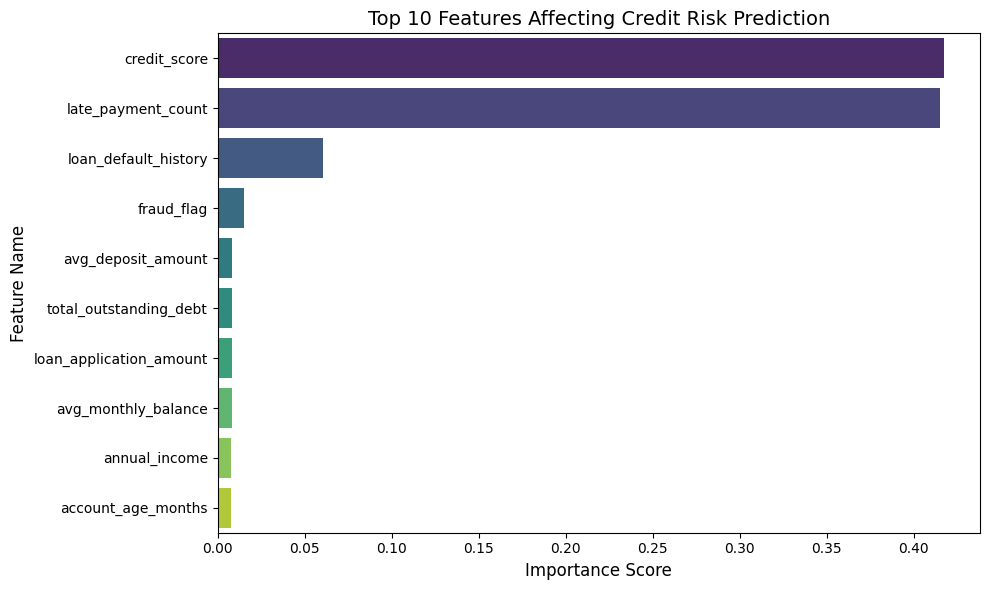


💡 Insight: Features with higher importance have more impact on the decision
   whether to approve or reject a loan application.


In [15]:
# Cell 13: Display which features most influence the prediction
# This helps understand what factors matter most for credit scoring

print("📊 FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Get feature importance from Random Forest model
feature_importance = rf_clf.feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Display top 10 most important features
print("\n🔝 TOP 10 MOST IMPORTANT FEATURES:")
print("-"*40)
for i, row in importance_df.head(10).iterrows():
    print(f"   {row['Feature']}: {row['Importance']*100:.2f}%")

# Create bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.title('Top 10 Features Affecting Credit Risk Prediction', fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 Insight: Features with higher importance have more impact on the decision")
print("   whether to approve or reject a loan application.")